In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mean-field theory of equilibrium swelling of polymer networks

and the corresponding affine elastic constants.

In [2]:
from matscipy.calculators.hydrogel.reference_solutions.mean_field_lattices import CROSSLINK_VOLUMES, MeanFieldHydrogelLattice

In [3]:
N = 100 # Number of monomers per chain 
χ =-1 
kuhn =1 

In [4]:
ana = MeanFieldHydrogelLattice(N, 4, CROSSLINK_VOLUMES['diamond'], flory_chi = χ, )

In [5]:
ana.compute_equilibrium_radius()

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:235: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)


np.float64(17.232643947146283)

In [6]:
chi = np.linspace(-1.0, 1.5, 100)
reqs = []
energies = []
c44 = []
c11 = []
c12 = []

bulk_modulus = []
shear_modulus = []
youngs_modulus = []
poisson_ratio = []

for c in chi:
    ana = MeanFieldHydrogelLattice(N, 4, CROSSLINK_VOLUMES['diamond'], flory_chi = c, )
    req = ana.compute_equilibrium_radius()
    reqs.append(req)
    energies.append(ana.total_energy(r=req))
    c44.append(ana.C44(r=req))
    c11.append(ana.C11(r=req))
    c12.append(ana.C12(r=req))

    bulk_modulus.append(ana.bulk_modulus(r=req))
    shear_modulus.append(ana.shear_modulus(r=req))
    youngs_modulus.append(ana.youngs_modulus(r=req))
    poisson_ratio.append(ana.poisson_ratio(r=req))




energies = np.array(energies)
reqs = np.array(reqs)
c44 = np.array(c44)
c11 = np.array(c11)
c12 = np.array(c12)

poisson_ratio = np.array(poisson_ratio)
youngs_modulus = np.array(youngs_modulus)
shear_modulus = np.array(shear_modulus)     
bulk_modulus = np.array(bulk_modulus)


/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:175: RuntimeWarning: invalid value encountered in log
  return  (1/ (vchain) * ϕ * np.log(ϕ) + 1/v0 * (1 - ϕ) * np.log(1 - ϕ) + 1/v0 * χ * ϕ * (1 - ϕ))


Text(0.5, 0, 'Flory parameter $\\chi$')

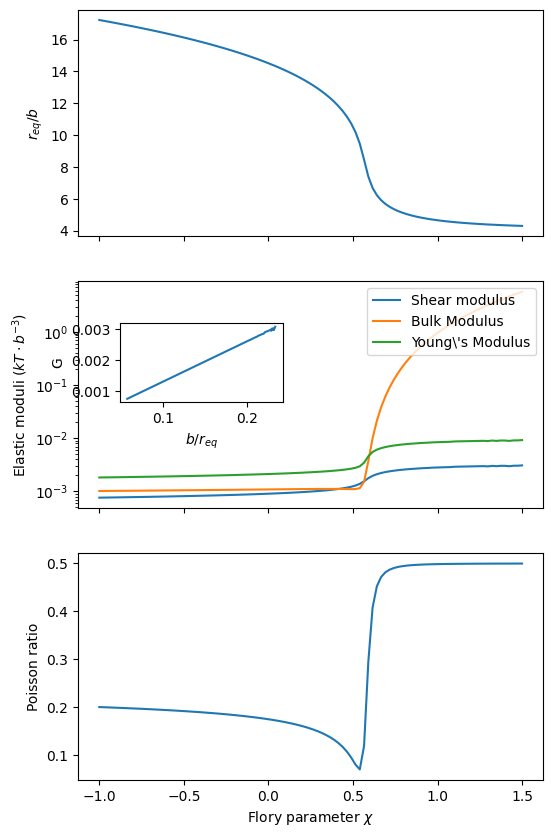

In [7]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 10))
ax = axes[0]

ax.plot(chi, reqs)

# ax.set_xlabel('Flory parameter $\chi$')
ax.set_ylabel('$r_{eq} / b$')

ax = axes[1]
ax.plot(chi, shear_modulus, label=r'Shear modulus')
ax.plot(chi, bulk_modulus, label=r'Bulk Modulus')
ax.plot(chi, youngs_modulus, label=r'Young\'s Modulus')
ax.legend(loc='upper right')

ax.set_ylabel('Elastic moduli $(kT \cdot b^{-3})$')

# ax.set_ylim(top=0.)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(
    ax,
    width="35%",   # relative to parent axis
    height="35%",
    loc="upper left",
    borderpad=3.0
)

ax.set_yscale('log')
# Example content
axins.plot(1/reqs, c44, label=r'Shear modulus')
axins.set_ylabel('G')
axins.set_xlabel(r'$b / r_{eq}$')

ax = axes[2]
ax.plot(chi, poisson_ratio, label=r'Poisson ratio')
ax.set_ylabel('Poisson ratio')

ax.set_xlabel('Flory parameter $\chi$')


## Convergence of the Manybody embedding energy towards the mean-field limit

In [8]:
from ase.build import bulk
from ase.optimize import FIRE

from matscipy.calculators.hydrogel import Hydrogel
from matscipy.elasticity import Voigt_6x6_to_cubic, fit_elastic_constants
from matscipy.molecules import Molecules
from matscipy.neighbours import neighbour_list

def create_diamond_hydrogel(crosslink_spacing = 1, n_cells=2):
    """Create a diamond lattice hydrogel.

    Parameters
    ----------
    crosslink_spacing : float
        Distance between crosslinkers
    n_cells : int
        Number of unit cells in each direction

    Returns
    -------
    atoms : ase.Atoms
        ASE Atoms object with the hydrogel structure
    molecules : matscipy.molecules.Molecules
        Bond topology
    """


    # Diamond lattice constant (nearest neighbor distance = a*sqrt(3)/4)
    # We want nearest neighbor distance = R0
    a = crosslink_spacing * 4 / np.sqrt(3)

    # Create diamond lattice
    atoms = bulk("C", "diamond", a=a, cubic=True)
    atoms = atoms.repeat((n_cells, n_cells, n_cells))

    # Set masses (LJ units)
    atoms.set_masses(np.ones(len(atoms)))

    # Create bonds between nearest neighbors
    # Nearest neighbor distance in diamond is a*sqrt(3)/4 = R0
    nn_dist = a * np.sqrt(3) / 4
    i_p, j_p = neighbour_list("ij", atoms, nn_dist * 1.1)

    # Keep only unique bonds (i < j)
    mask = i_p < j_p
    bonds = np.column_stack([i_p[mask], j_p[mask]])

    molecules = Molecules(bonds_connectivity=bonds)

    return atoms, molecules

In [9]:
from matscipy.calculators.hydrogel.potentials import GaussianChain

In [10]:

# Derived parameters
Re = np.sqrt(N) * kuhn  # RMS end-to-end distance of a free chain
rc = 6*Re  
ana = MeanFieldHydrogelLattice(N, 4, CROSSLINK_VOLUMES['diamond'], flory_chi = χ, )
atoms, molecules = create_diamond_hydrogel(crosslink_spacing=4* Re, n_cells=2)
calc = Hydrogel(
    cutoff=rc,
    chain_monomers=N,
    kuhn_length=kuhn,
    monomer_volume=ana.v0,
    flory_chi=χ ,
    coordination=ana.coordination,
    molecules=molecules,
    chain=GaussianChain(
        kuhn_length=kuhn,
        chain_monomers=N,
    ),
)
atoms.calc = calc

In [11]:
stresses = []
energies = []
distances = []
scale_factors = np.linspace(0.1, 1.10, 100)
cell = atoms.get_cell()

for scale in scale_factors:
    # Scale cell
    new_cell = cell * scale
    atoms.set_cell(new_cell, scale_atoms=True)


    # Record stress and energy
    stress = atoms.get_stress(voigt=True)
    # Ebergy per crosslink
    energy = atoms.get_potential_energy() / len(atoms)
    
    stresses.append(stress)
    energies.append(energy)
    
    bond_lengths = molecules.get_distances(atoms) 
    # print(f'minimum bond distances: {np.min(bond_lengths)}')
    # print(f'maximum bond distances: {np.max(bond_lengths)}')

    distances.append(np.mean(bond_lengths))



In [12]:
len(atoms)

64

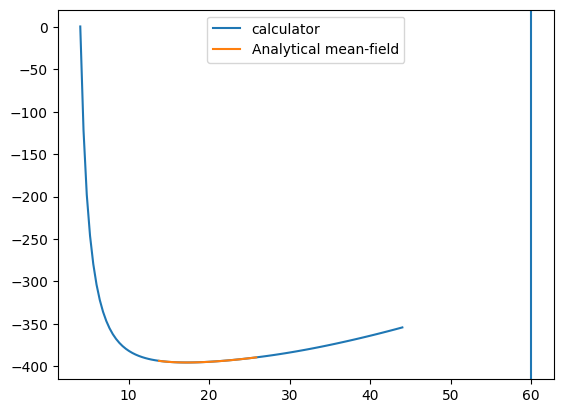

In [13]:
fig, ax = plt.subplots()
ax.plot(distances, energies, label='calculator')
ax.axvline(rc)

rs = np.linspace(0.8, 1.5 ) * ana.compute_equilibrium_radius()

ax.plot(rs, ana.total_energy(r=rs), label='Analytical mean-field')

ax.legend()
